# Semai Mohammed
## Lab 03 Assignment

## Imports

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

import tools
from my_functions import (
    get_gaussian_filtre,
    filter_analysis,
    filter_analysis_colored,
    apply_filter_to_single_channel,
    apply_filter_to_colored_img,
    get_Gx, get_Gy, get_L,
    module_grad, direct_grad,
    image_gradient,
    gradient_orientation_8dirs,
)

print('Imports OK')

Imports OK


---
## New functions

In [2]:
def get_averaging_filter(dimension=3):
    """
    Build a normalised averaging (box) kernel of shape (dimension x dimension).
    Every coefficient equals 1/(dimension*dimension) so the sum equals 1.
    Similar to get_gaussian_filtre but with uniform weights.
    """
    return np.ones((dimension, dimension), dtype=float) / (dimension * dimension)


def edge_detection_gradient(img, threshold=50):
    """
    First-order edge detection using gradient magnitude thresholding.
    A pixel is classified as an edge if its gradient magnitude >= threshold.
    Returns:
        GI    : gradient magnitude map
        edges : binary edge map (0 or 255)
    """
    GI    = module_grad(img)
    edges = (GI >= threshold).astype(np.uint8) * 255
    return GI, edges


def zero_crossings(img, threshold=10):
    """
    Detect zero crossings of the Laplacian LI = I * L.
    For each pixel (i,j), examine its 3x3 neighbourhood:
      - max(LI) > 0
      - min(LI) < 0
      - max(LI) - min(LI) > threshold
    If all three conditions hold, (i,j) is an edge pixel.
    Returns:
        LI    : Laplacian response
        edges : binary edge map (0 or 255)
    """
    LI    = get_L(img)
    h, w  = LI.shape
    edges = np.zeros((h, w), dtype=np.uint8)

    for i in range(1, h - 1):
        for j in range(1, w - 1):
            patch = LI[i-1:i+2, j-1:j+2]
            mx, mn = patch.max(), patch.min()
            if mx > 0 and mn < 0 and (mx - mn) > threshold:
                edges[i, j] = 255

    return LI, edges


def non_maxima_suppression(GI, thetaI):
    """
    Non-Maxima Suppression (NMS).
    Suppress pixels whose gradient magnitude is not a local maximum
    in the direction of the gradient vector.

    The angle thetaI (radians) is mapped to 4 discrete directions:
        0   deg -> horizontal  (regions: 0–22.5, 157.5–180)
        45  deg -> diagonal /  (regions: 22.5–67.5)
        90  deg -> vertical    (regions: 67.5–112.5)
        135 deg -> diagonal \  (regions: 112.5–157.5)

    Returns I_NMS: gradient image after suppression.
    """
    h, w  = GI.shape
    I_NMS = np.zeros_like(GI)
    angle = np.rad2deg(thetaI) % 180   # map to [0, 180)

    for i in range(1, h - 1):
        for j in range(1, w - 1):
            a = angle[i, j]

            if (0 <= a < 22.5) or (157.5 <= a < 180):  # 0 deg — horizontal
                n1, n2 = GI[i, j-1], GI[i, j+1]
            elif 22.5 <= a < 67.5:                       # 45 deg
                n1, n2 = GI[i-1, j+1], GI[i+1, j-1]
            elif 67.5 <= a < 112.5:                      # 90 deg — vertical
                n1, n2 = GI[i-1, j], GI[i+1, j]
            else:                                         # 135 deg
                n1, n2 = GI[i-1, j-1], GI[i+1, j+1]

            if GI[i, j] >= n1 and GI[i, j] >= n2:
                I_NMS[i, j] = GI[i, j]

    return I_NMS


print('New functions defined: get_averaging_filter, edge_detection_gradient,',
      'zero_crossings, non_maxima_suppression')

New functions defined: get_averaging_filter, edge_detection_gradient, zero_crossings, non_maxima_suppression


---
# Part 1 — Smoothing Filters

## 1.1 — Averaging filter on `flower.png` (grayscale) — sizes 3, 7, 11

flower_gray shape: (318, 396)
  size 3x3 -> output shape: (318, 396)  (same as input: True)
  size 7x7 -> output shape: (318, 396)  (same as input: True)
  size 11x11 -> output shape: (318, 396)  (same as input: True)


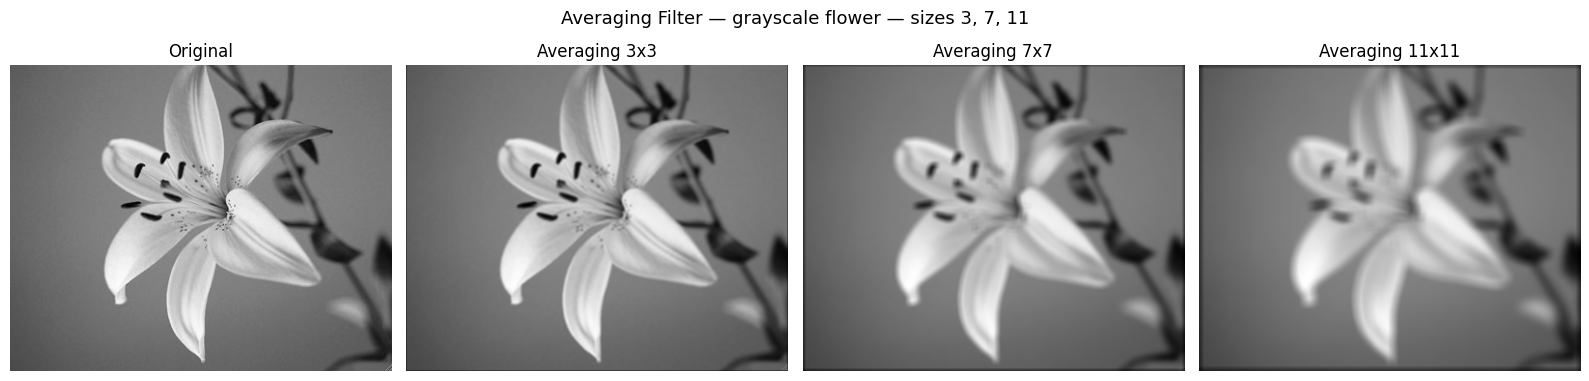

In [3]:
# Read flower in grayscale
flower_gray = cv2.imread('flower.png', cv2.IMREAD_GRAYSCALE)
print(f'flower_gray shape: {flower_gray.shape}')

filter_sizes  = [3, 7, 11]
filtered_imgs = []

for k in filter_sizes:
    kernel   = get_averaging_filter(k)
    filtered = apply_filter_to_single_channel(flower_gray.astype(float), kernel)
    filtered_imgs.append(filtered)
    print(f'  size {k}x{k} -> output shape: {filtered.shape}  '
          f'(same as input: {filtered.shape == flower_gray.shape})')

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(flower_gray, cmap='gray'); axes[0].set_title('Original'); axes[0].axis('off')
for ax, filt, k in zip(axes[1:], filtered_imgs, filter_sizes):
    ax.imshow(filt, cmap='gray')
    ax.set_title(f'Averaging {k}x{k}')
    ax.axis('off')
fig.suptitle('Averaging Filter grayscale flower sizes 3, 7, 11', fontsize=13)
plt.tight_layout(); plt.show()

### Comment — effect of filter size

The averaging (box) filter replaces each pixel with the **mean of its neighbourhood**. As the kernel size increases:

- **3×3**: slight smoothing; fine noise is attenuated while edges and texture are largely preserved.
- **7×7**: moderate blur; thin structures (stamens, leaf edges) start to merge; noise is significantly reduced.
- **11×11**: strong blur; fine details are lost and the image looks noticeably softer. Larger kernels average over a wider area, inherently discarding high-frequency information (edges, texture).

In all cases the **output dimensions equal the input dimensions** because symmetric zero-padding of size `(k-1)//2` is applied on each border before convolution.

## 1.2 — Averaging vs Gaussian (7×7) on grayscale flower

`filter_analysis(img, kernel)` from `my_functions.py` is used directly.

Averaging filter


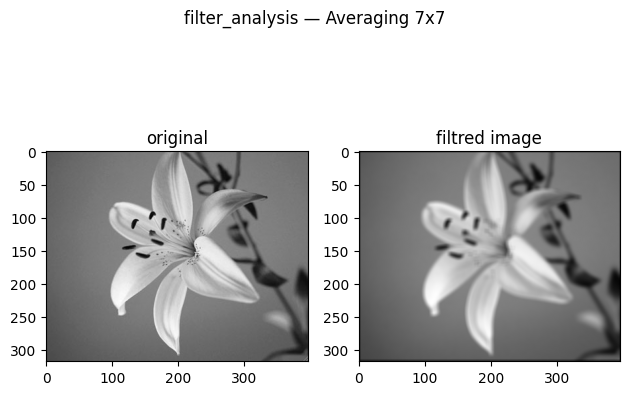

Gaussian filter


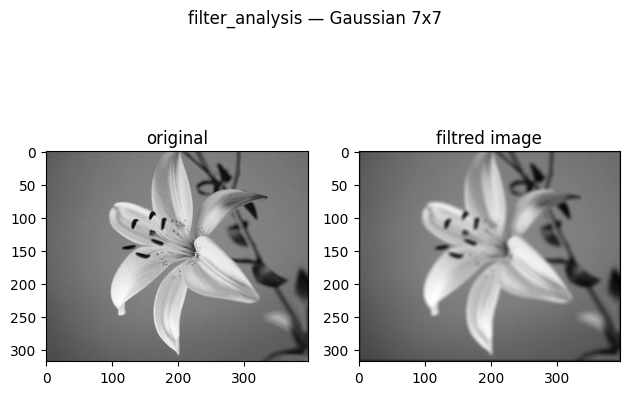

In [4]:
DIM = 7
flower_f = flower_gray.astype(float)

k_avg   = get_averaging_filter(DIM)
k_gauss = get_gaussian_filtre(DIM)

print('Averaging filter')
filter_analysis(flower_gray, k_avg)
plt.suptitle(f'filter_analysis — Averaging {DIM}x{DIM}', fontsize=12)
plt.tight_layout(); plt.show()

print('Gaussian filter')
filter_analysis(flower_gray, k_gauss)
plt.suptitle(f'filter_analysis — Gaussian {DIM}x{DIM}', fontsize=12)
plt.tight_layout(); plt.show()

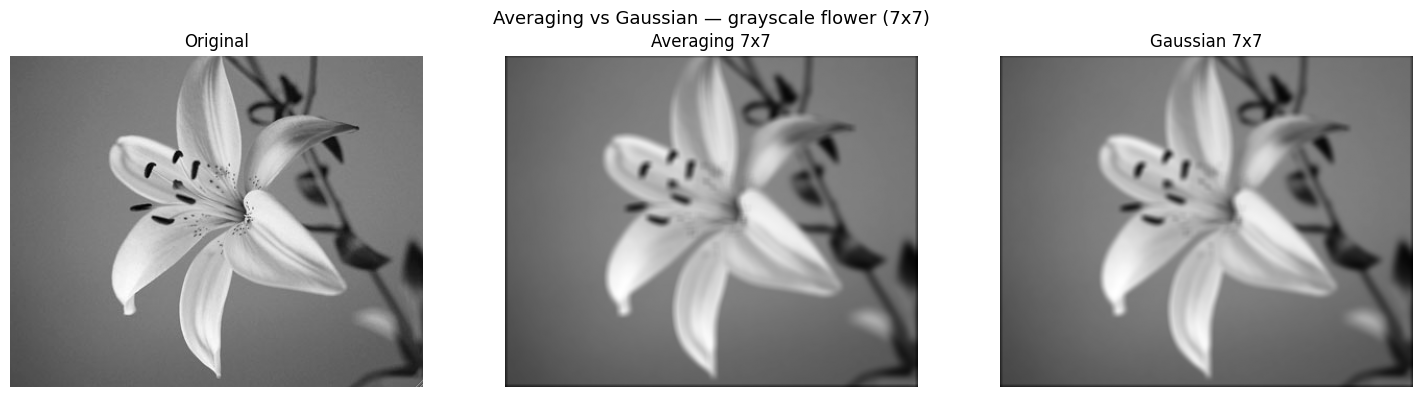

Averaging kernel (7x7):
[[0.0204 0.0204 0.0204 0.0204 0.0204 0.0204 0.0204]
 [0.0204 0.0204 0.0204 0.0204 0.0204 0.0204 0.0204]
 [0.0204 0.0204 0.0204 0.0204 0.0204 0.0204 0.0204]
 [0.0204 0.0204 0.0204 0.0204 0.0204 0.0204 0.0204]
 [0.0204 0.0204 0.0204 0.0204 0.0204 0.0204 0.0204]
 [0.0204 0.0204 0.0204 0.0204 0.0204 0.0204 0.0204]
 [0.0204 0.0204 0.0204 0.0204 0.0204 0.0204 0.0204]]

Gaussian kernel (7x7):
[[0.0133 0.0163 0.0184 0.0192 0.0184 0.0163 0.0133]
 [0.0163 0.02   0.0226 0.0236 0.0226 0.02   0.0163]
 [0.0184 0.0226 0.0256 0.0266 0.0256 0.0226 0.0184]
 [0.0192 0.0236 0.0266 0.0277 0.0266 0.0236 0.0192]
 [0.0184 0.0226 0.0256 0.0266 0.0256 0.0226 0.0184]
 [0.0163 0.02   0.0226 0.0236 0.0226 0.02   0.0163]
 [0.0133 0.0163 0.0184 0.0192 0.0184 0.0163 0.0133]]


In [5]:
# comparison
avg_out   = apply_filter_to_single_channel(flower_f, k_avg)
gauss_out = apply_filter_to_single_channel(flower_f, k_gauss)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(flower_gray, cmap='gray'); axes[0].set_title('Original');        axes[0].axis('off')
axes[1].imshow(avg_out,     cmap='gray'); axes[1].set_title('Averaging 7x7');   axes[1].axis('off')
axes[2].imshow(gauss_out,   cmap='gray'); axes[2].set_title('Gaussian 7x7');    axes[2].axis('off')
fig.suptitle('Averaging vs Gaussian — grayscale flower (7x7)', fontsize=13)
plt.tight_layout(); plt.show()

print('Averaging kernel (7x7):')
print(np.round(k_avg, 4))
print('\nGaussian kernel (7x7):')
print(np.round(k_gauss, 4))

### Comment — Averaging vs Gaussian

| | Averaging | Gaussian |
|---|---|---|
| Weights | Uniform (all = 1/k²) | Bell-shaped (centre weighted more) |
| Blur character | Flat / blocky | Smooth, natural |
| Edge preservation | Weaker | Better |
| Noise reduction | Good | Good |

The Gaussian filter produces a more visually natural blur because pixels closer to the centre contribute more. The averaging filter gives equal weight to every neighbour, including far ones, which creates a slightly "blocky" appearance. For photographic content the Gaussian is generally preferred.

## 1.3 — Colour image `red_bird.png` with `filter_analysis_colored`

red_bird shape: (152, 204, 3)
Averaging


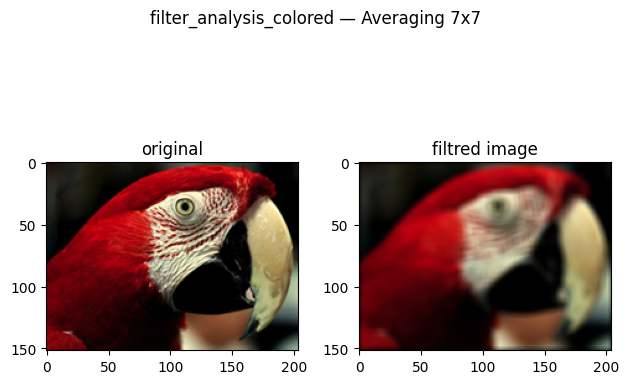

 Gaussian


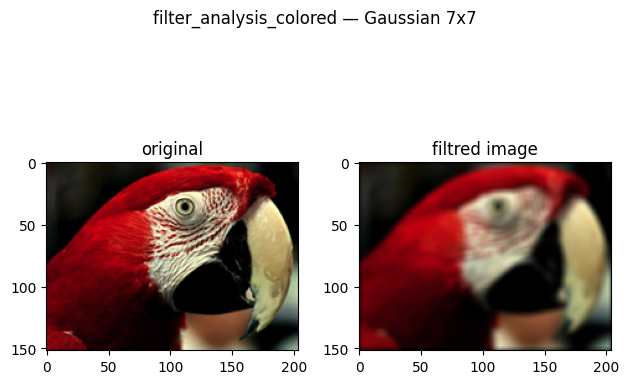

In [6]:
bird_bgr = cv2.imread('red_bird.png')
bird_rgb = cv2.cvtColor(bird_bgr, cv2.COLOR_BGR2RGB)
print(f'red_bird shape: {bird_rgb.shape}')

print('Averaging')
filter_analysis_colored(bird_rgb, k_avg)
plt.suptitle(f'filter_analysis_colored — Averaging {DIM}x{DIM}', fontsize=12)
plt.tight_layout(); plt.show()

print(' Gaussian')
filter_analysis_colored(bird_rgb, k_gauss)
plt.suptitle(f'filter_analysis_colored — Gaussian {DIM}x{DIM}', fontsize=12)
plt.tight_layout(); plt.show()

### Comment — colour image

The filter is applied independently to each R, G, B channel using `apply_filter_to_colored_img`. The qualitative behaviour is identical to the grayscale case: the Gaussian preserves colour gradients and fine plumage details better than the averaging filter, which tends to wash out fine colour transitions. Colour integrity is maintained in both cases because each channel is processed symmetrically.

---
# Part 2 — Discrete Filters & Edge Detection

> All experiments below use **`flower.png`** (grayscale).

In [7]:
flower_gray = cv2.imread('flower.png', cv2.IMREAD_GRAYSCALE)
flower_f    = flower_gray.astype(float)
print(f'flower_gray shape: {flower_gray.shape}')

flower_gray shape: (318, 396)


## 2.1 — Sobel gradients Gx and Gy

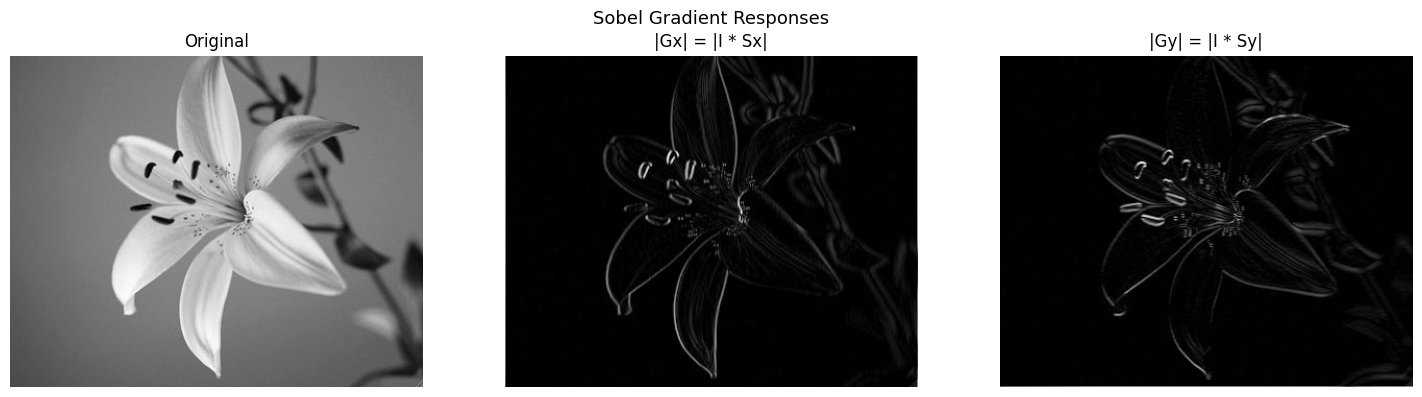

Gx — min: -749.0  max: 714.0
Gy — min: -729.0  max: 642.0


In [8]:
Gx = get_Gx(flower_f)
Gy = get_Gy(flower_f)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(flower_gray,  cmap='gray'); axes[0].set_title('Original');   axes[0].axis('off')
axes[1].imshow(np.abs(Gx),  cmap='gray'); axes[1].set_title('|Gx| = |I * Sx|'); axes[1].axis('off')
axes[2].imshow(np.abs(Gy),  cmap='gray'); axes[2].set_title('|Gy| = |I * Sy|'); axes[2].axis('off')
fig.suptitle('Sobel Gradient Responses', fontsize=13)
plt.tight_layout(); plt.show()

print(f'Gx — min: {Gx.min():.1f}  max: {Gx.max():.1f}')
print(f'Gy — min: {Gy.min():.1f}  max: {Gy.max():.1f}')

### Comment — Gx and Gy

- **Gx** (Sx kernel): highlights **vertical edges** — transitions along the horizontal axis. The left and right contours of petals appear bright.
- **Gy** (Sy kernel): highlights **horizontal edges** — transitions along the vertical axis. Top and bottom petal boundaries are emphasised.

Both responses are signed (positive or negative depending on the direction of the intensity change), so absolute values are displayed. The Sobel operator is a first-derivative approximation and responds strongly wherever intensity changes rapidly.

## 2.2 — Gradient magnitude GI and direction θI

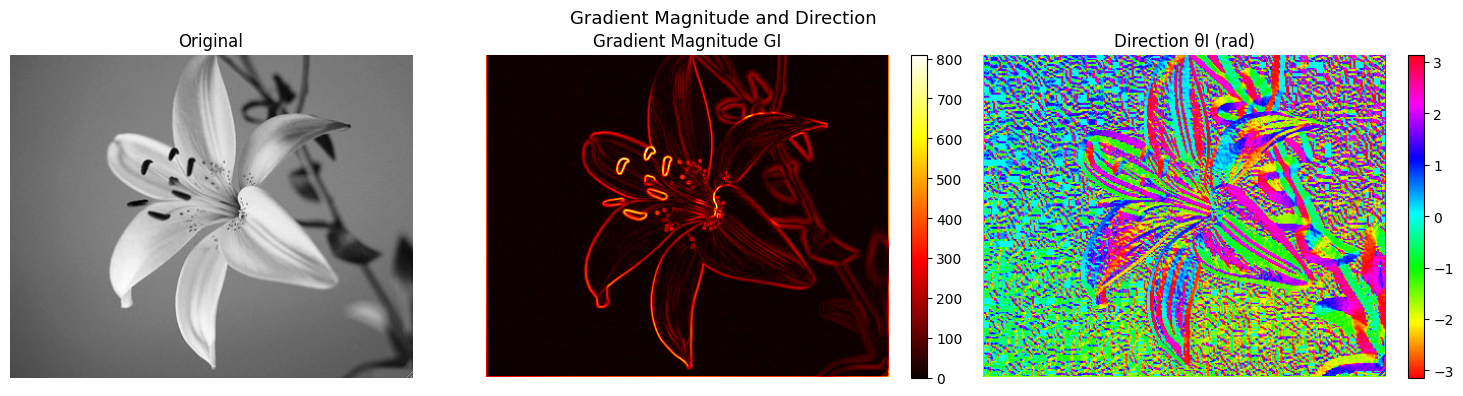

GI     — min: 0.0  max: 809.8
thetaI — min: -179.9°  max: 180.0°


In [9]:
Gx, Gy, GI, thetaI = image_gradient(flower_f)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(flower_gray, cmap='gray');  axes[0].set_title('Original');              axes[0].axis('off')
im1 = axes[1].imshow(GI,   cmap='hot');   axes[1].set_title('Gradient Magnitude GI'); axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046)
im2 = axes[2].imshow(thetaI, cmap='hsv'); axes[2].set_title('Direction θI (rad)');    axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046)
fig.suptitle('Gradient Magnitude and Direction', fontsize=13)
plt.tight_layout(); plt.show()

print(f'GI     — min: {GI.min():.1f}  max: {GI.max():.1f}')
print(f'thetaI — min: {np.degrees(thetaI.min()):.1f}°  max: {np.degrees(thetaI.max()):.1f}°')

### Comment — Magnitude and Direction

- **GI = √(Gx² + Gy²)**: combines both partial derivatives into a single edge strength map, regardless of direction. High values (bright in the heat map) correspond to strong edges — the flower's petals and stamens produce the highest magnitudes.
- **θI = arctan2(Gy, Gx)**: encodes the orientation of the intensity change, ranging from −π to π. Uniform background regions have near-zero GI so their θI is essentially noise; only edge pixels carry meaningful directional information.

## 2.3 — Gradient orientation map (8 discrete bins)

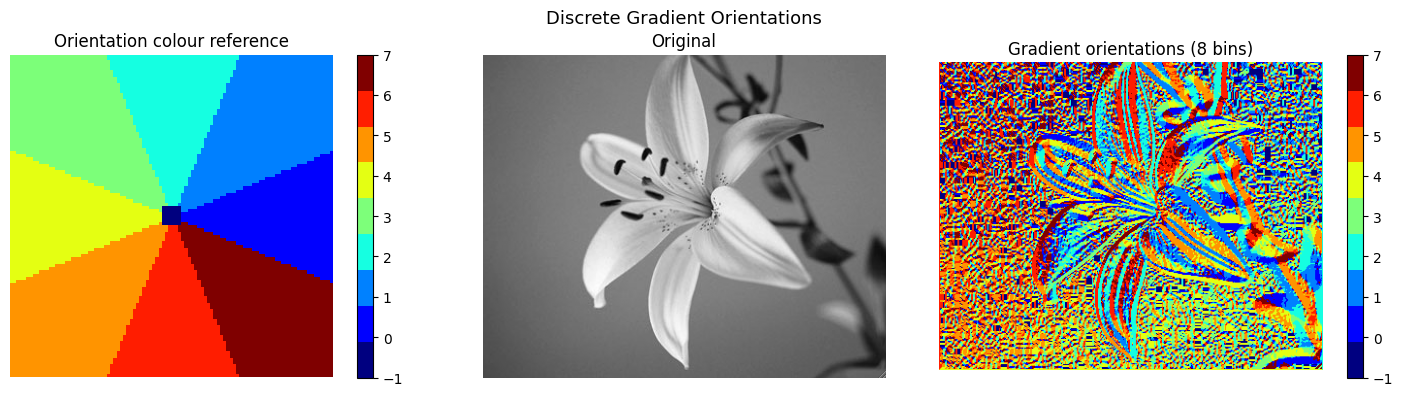

In [10]:
bins   = 8
cmap   = tools.cmap_discretize('jet', bins + 1)
ori_map = tools.orientation_colors()

Gx, Gy, GI, thetaI, g_o = gradient_orientation_8dirs(flower_f, b=bins)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].imshow(ori_map, cmap=cmap, vmin=-1, vmax=bins-1)
plt.colorbar(im0, ax=axes[0])
axes[0].set_title('Orientation colour reference'); axes[0].axis('off')

axes[1].imshow(flower_gray, cmap='gray'); axes[1].set_title('Original'); axes[1].axis('off')

im2 = axes[2].imshow(g_o, cmap=cmap, vmin=-1, vmax=bins-1)
plt.colorbar(im2, ax=axes[2])
axes[2].set_title('Gradient orientations (8 bins)'); axes[2].axis('off')

fig.suptitle('Discrete Gradient Orientations', fontsize=13)
plt.tight_layout(); plt.show()

### Comment — Discrete orientations

The 8-bin orientation map quantises the continuous angle θI into 8 evenly-spaced directions (0°, 45°, 90°, …, 315°). Pixels with zero gradient magnitude receive the label −1 (dark violet in the colormap).

Comparing the map with the flower image:
- Left/right petal edges → horizontal bins (≈ 0° / 180°).
- Top/bottom petal edges → vertical bins (≈ 90° / 270°).
- Diagonal petal contours → 45° / 135° bins.

This orientation representation is the building block of HOG descriptors and the Canny edge detector.

## 2.4 — First-order edge detection with gradient thresholding

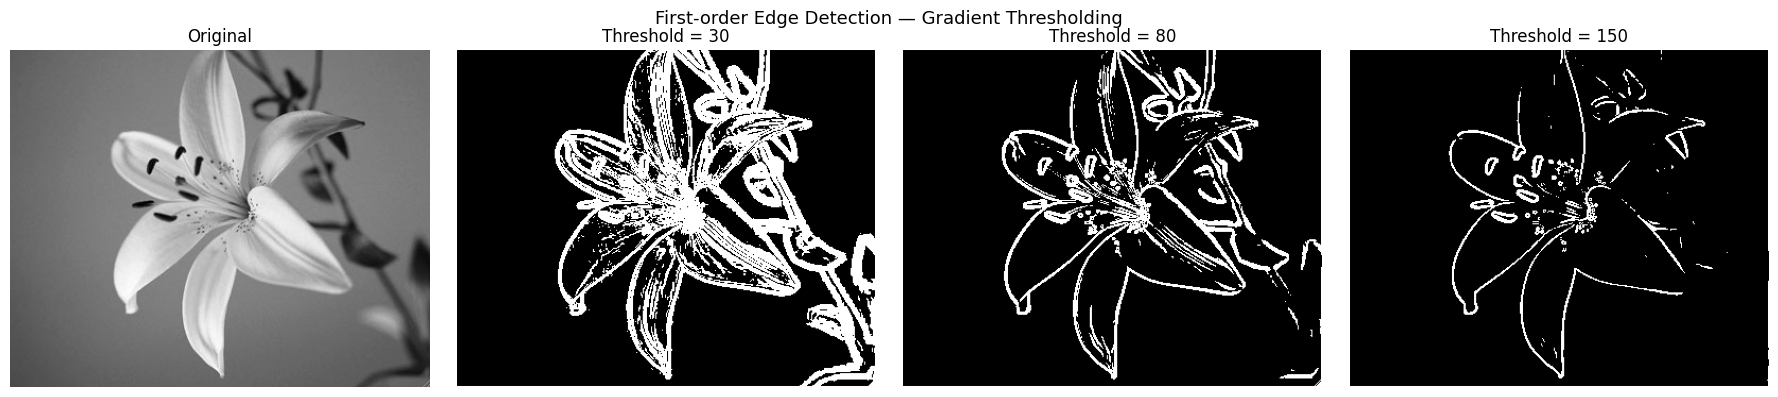

In [11]:
thresholds = [30, 80, 150]

fig, axes = plt.subplots(1, len(thresholds) + 1, figsize=(18, 4))
axes[0].imshow(flower_gray, cmap='gray'); axes[0].set_title('Original'); axes[0].axis('off')

for ax, thr in zip(axes[1:], thresholds):
    GI_t, edges = edge_detection_gradient(flower_f, threshold=thr)
    ax.imshow(edges, cmap='gray')
    ax.set_title(f'Threshold = {thr}')
    ax.axis('off')

fig.suptitle('First-order Edge Detection — Gradient Thresholding', fontsize=13)
plt.tight_layout(); plt.show()

### Comment — Gradient thresholding

A pixel is labelled as an edge if GI ≥ threshold:

- **Low threshold (30)**: nearly all intensity changes detected, including noise and fine texture — many false positives.
- **Medium threshold (80)**: main petal contours well-preserved; most noise suppressed — a reasonable balance.
- **High threshold (150)**: only the strongest edges (deep dark-to-light transitions) survive; fine details and weak edges are lost.

A major limitation of this simple approach is that edges are **multi-pixel wide** (thick bands), unlike the thin contours produced after NMS.

## 2.5 — Laplacian filter LI = I ⊛ L

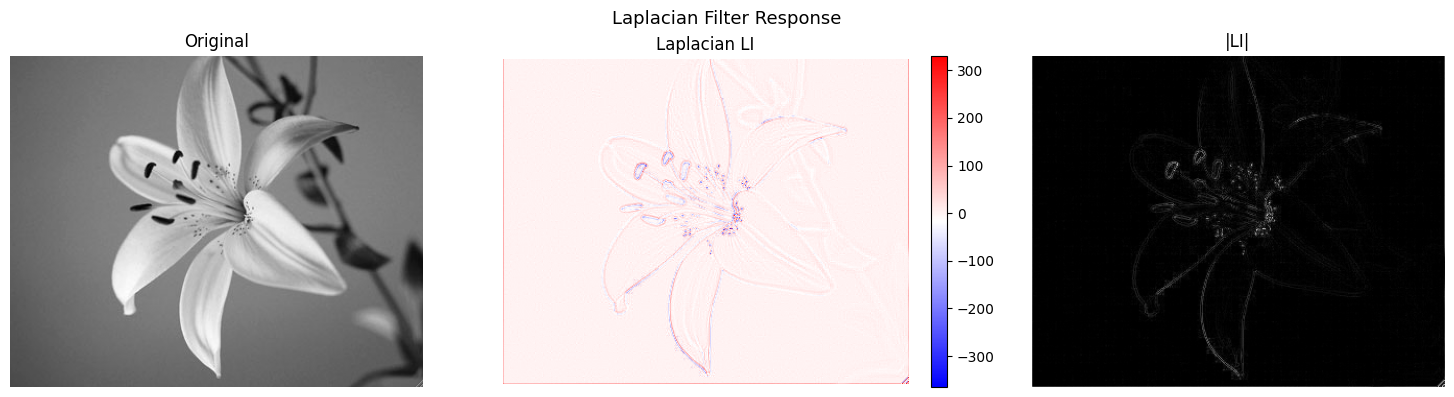

LI — min: -365.0  max: 331.0  mean: 1.069


In [12]:
LI = get_L(flower_f)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(flower_gray,   cmap='gray'); axes[0].set_title('Original');    axes[0].axis('off')
im1 = axes[1].imshow(LI,     cmap='bwr');  axes[1].set_title('Laplacian LI'); axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046)
axes[2].imshow(np.abs(LI),   cmap='gray'); axes[2].set_title('|LI|');         axes[2].axis('off')
fig.suptitle('Laplacian Filter Response', fontsize=13)
plt.tight_layout(); plt.show()

print(f'LI — min: {LI.min():.1f}  max: {LI.max():.1f}  mean: {LI.mean():.3f}')

### Comment — Laplacian response

The Laplacian approximates the second spatial derivative (∂²I/∂x² + ∂²I/∂y²). Key properties:

- **Isotropic**: responds equally to edges in all directions, unlike the directional Sobel.
- **Zero-mean kernel**: uniform regions produce a response of zero.
- **Sign change at edges**: LI is positive on one side and negative on the other — the **zero crossing** pinpoints the exact edge location.
- **Noise-sensitive**: differentiation amplifies high-frequency components, so pre-smoothing (Laplacian of Gaussian, LoG) is recommended in practice.

## 2.6 — Zero crossings of LI

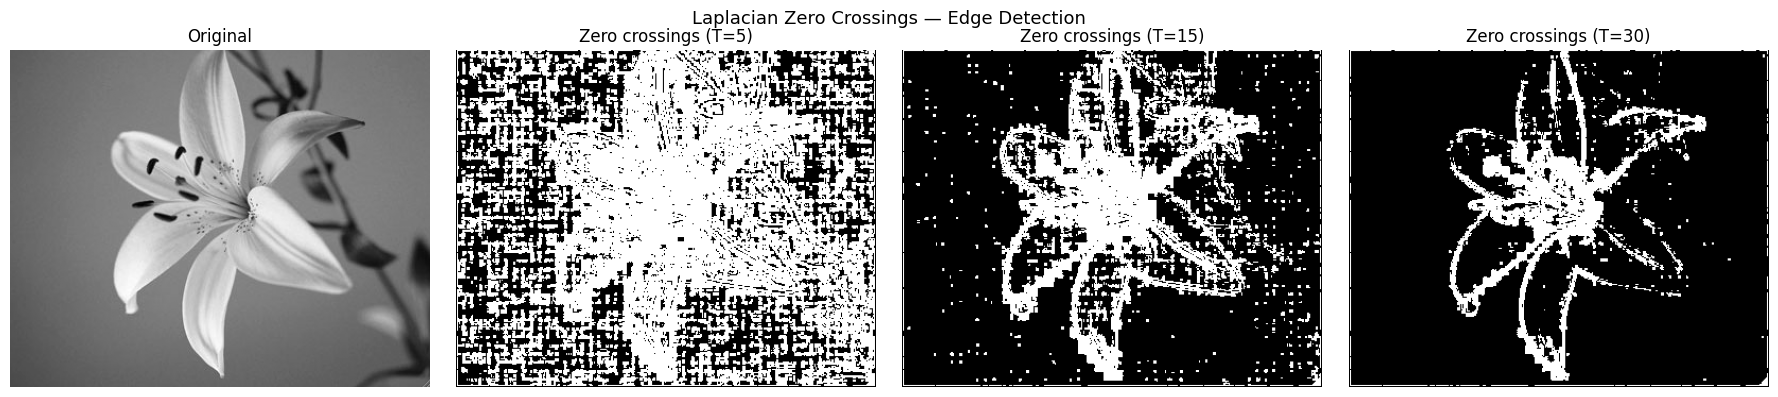

In [13]:
thresholds_zc = [5, 15, 30]

fig, axes = plt.subplots(1, len(thresholds_zc) + 1, figsize=(18, 4))
axes[0].imshow(flower_gray, cmap='gray'); axes[0].set_title('Original'); axes[0].axis('off')

for ax, thr in zip(axes[1:], thresholds_zc):
    _, zc_edges = zero_crossings(flower_f, threshold=thr)
    ax.imshow(zc_edges, cmap='gray')
    ax.set_title(f'Zero crossings (T={thr})')
    ax.axis('off')

fig.suptitle('Laplacian Zero Crossings — Edge Detection', fontsize=13)
plt.tight_layout(); plt.show()

### Comment — Zero crossings

Zero crossings mark the sign change of LI, which corresponds to the **inflection point** of intensity — the true edge location. The threshold controls the minimum required contrast:

- **T=5**: very sensitive; noise and fine texture produce many spurious closed contours.
- **T=15**: meaningful petal and stamen contours emerge; most noise suppressed.
- **T=30**: only the highest-contrast boundaries survive; fine details lost.

A key advantage over gradient thresholding: zero-crossing edges are naturally **one pixel thin** and form closed contours, which is useful for segmentation.

---
# Part 3 — Smoothing & Non-Maxima Suppression

## 3.1 — NMS: compare GI vs I_NMS

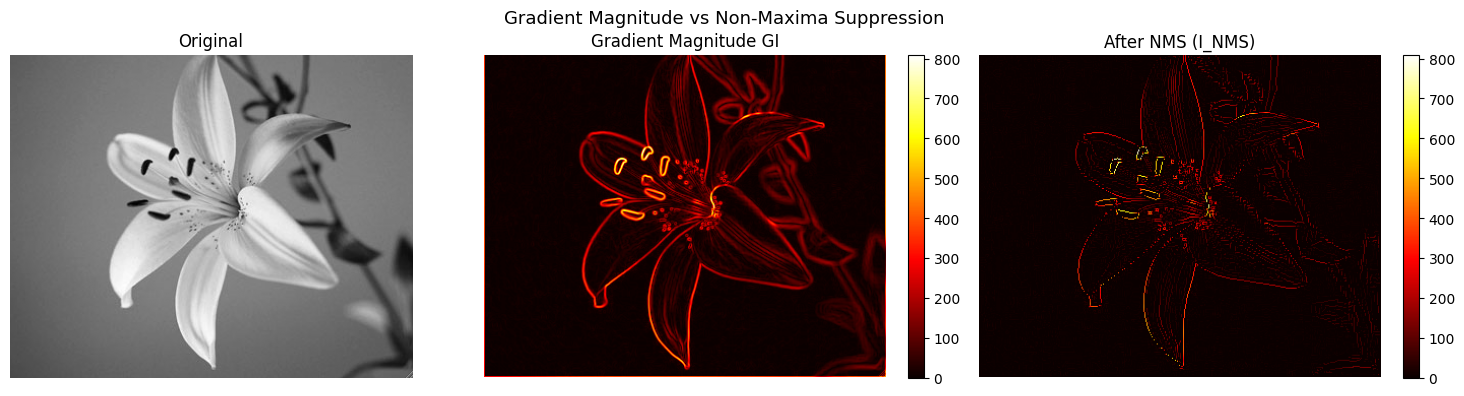

Non-zero pixels — GI: 120473   I_NMS: 35921  (reduced by 70.2%)


In [14]:
Gx, Gy, GI, thetaI = image_gradient(flower_f)
I_NMS = non_maxima_suppression(GI, thetaI)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(flower_gray, cmap='gray');  axes[0].set_title('Original');             axes[0].axis('off')
im1 = axes[1].imshow(GI,   cmap='hot');   axes[1].set_title('Gradient Magnitude GI'); axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046)
im2 = axes[2].imshow(I_NMS, cmap='hot');  axes[2].set_title('After NMS (I_NMS)');    axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046)
fig.suptitle('Gradient Magnitude vs Non-Maxima Suppression', fontsize=13)
plt.tight_layout(); plt.show()

nz_GI  = np.count_nonzero(GI   > 0)
nz_NMS = np.count_nonzero(I_NMS > 0)
print(f'Non-zero pixels — GI: {nz_GI}   I_NMS: {nz_NMS}  '
      f'(reduced by {100*(1 - nz_NMS/nz_GI):.1f}%)')

### Comment — GI vs I_NMS

NMS **thins** the wide edge ridges of the Sobel response into **single-pixel-wide** edge lines:

- In **GI**, every pixel near an edge has elevated magnitude — edges appear as thick bands several pixels wide.
- In **I_NMS**, only the pixel with the **locally maximum magnitude** in the gradient direction is retained; all others are set to 0.

The result is a significantly sparser map with crisper, more precisely localised edges. The number of non-zero pixels drops considerably (see output above). This thinning step is the key intermediate stage in the Canny edge detector.

## 3.2 — Effect of Gaussian smoothing σ on NMS edges

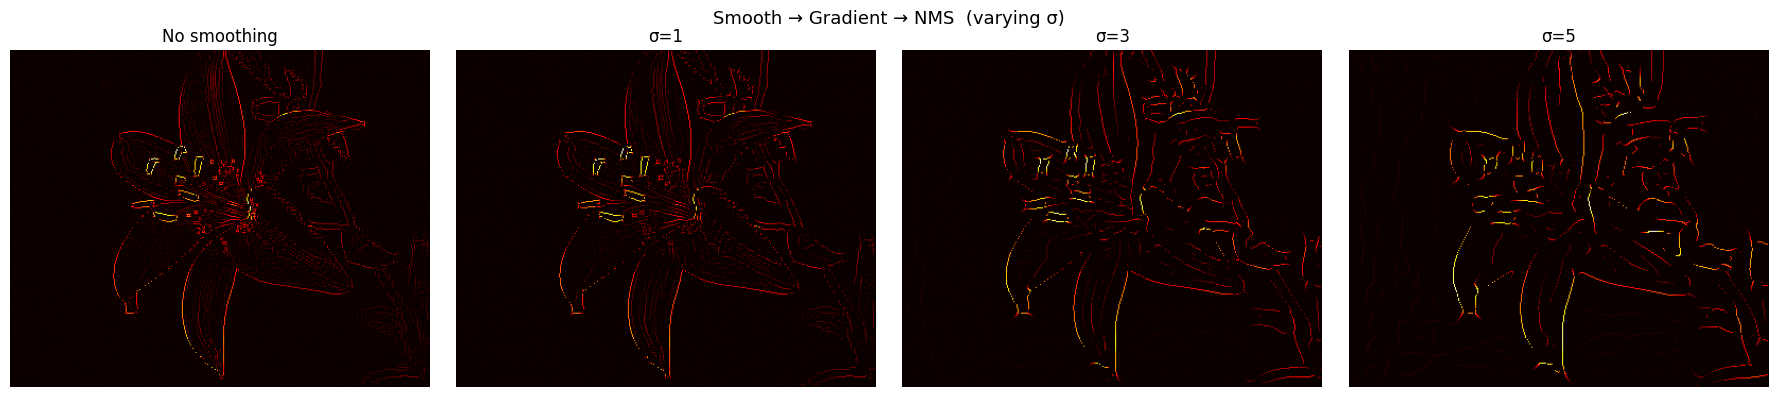

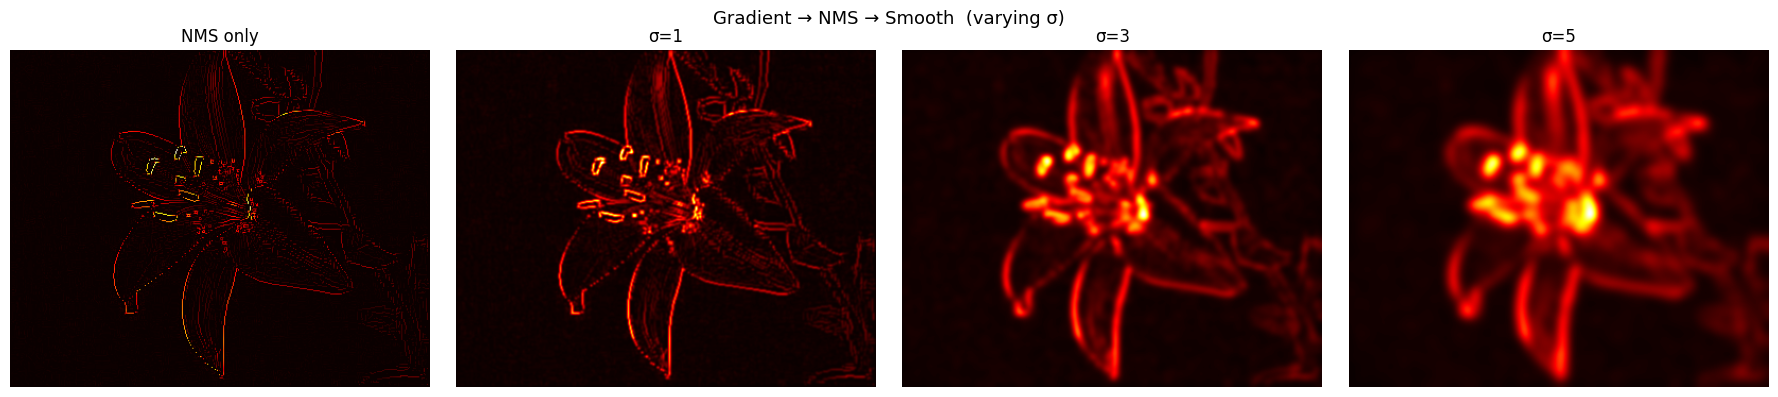

In [15]:
sigmas = [0, 1, 3, 5]

# A) Smooth BEFORE gradient + NMS  (recommended order)
fig, axes = plt.subplots(1, len(sigmas), figsize=(18, 4))
for ax, sigma in zip(axes, sigmas):
    img_s = ndimage.gaussian_filter(flower_f, sigma) if sigma > 0 else flower_f
    _, _, GI_s, theta_s = image_gradient(img_s)
    I_NMS_s = non_maxima_suppression(GI_s, theta_s)
    ax.imshow(I_NMS_s, cmap='hot')
    ax.set_title(f'σ={sigma}' if sigma > 0 else 'No smoothing')
    ax.axis('off')
fig.suptitle('Smooth → Gradient → NMS  (varying σ)', fontsize=13)
plt.tight_layout(); plt.show()

# B) Gradient + NMS THEN smooth
_, _, GI_raw, theta_raw = image_gradient(flower_f)
I_NMS_raw = non_maxima_suppression(GI_raw, theta_raw)

fig, axes = plt.subplots(1, len(sigmas), figsize=(18, 4))
for ax, sigma in zip(axes, sigmas):
    result = ndimage.gaussian_filter(I_NMS_raw, sigma) if sigma > 0 else I_NMS_raw
    ax.imshow(result, cmap='hot')
    ax.set_title(f'σ={sigma}' if sigma > 0 else 'NMS only')
    ax.axis('off')
fig.suptitle('Gradient → NMS → Smooth  (varying σ)', fontsize=13)
plt.tight_layout(); plt.show()

### Conclusion — Influence of σ and order of operations

**Smoothing before gradient + NMS (A — recommended):**

| σ | Effect |
|---|---|
| 0 (none) | Noisy; fine texture produces spurious edges; map is dense |
| 1 | Noise suppressed; main structural edges well-defined and thin |
| 3 | Only dominant edges survive; fine texture and thin structures vanish |
| 5 | Very few, very coarse edges remain; small objects completely lost |

Pre-smoothing before differentiation is standard practice because the derivative operator amplifies high-frequency noise. A small σ ≈ 1–2 gives a good balance between noise suppression and detail retention — this is exactly the principle behind **Canny** (Gaussian smoothing + Sobel + NMS + hysteresis thresholding) and **LoG** (Laplacian of Gaussian).

**Smoothing after NMS (B):**

Applying smoothing to the already-thinned NMS result simply **blurs** the sparse edge map back into thick bands, undoing the thinning — the opposite of what is desired. This order is therefore not useful for edge detection.

**Key takeaway:** σ is a **scale parameter** — it selects the spatial scale at which edges are detected. Higher σ reveals only large-scale (coarse) structure; lower σ preserves fine detail at the cost of noise sensitivity. The optimal σ depends on the application and the typical size of the objects of interest.